In [ ]:
# Εισαγωγή Βιβλιοθηκών 

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error
import holidays
from statsmodels.tsa.stattools import acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Input, Reshape
from tensorflow.keras.callbacks import EarlyStopping

In [ ]:
# Βήμα I: Προ-επεξεργασία Δεδομένων & Feature Engineering

In [ ]:
# 1. Λήψη και Φόρτωση Δεδομένων

In [2]:
# Φορτώνουμε το αρχείο, δηλώνοντας ότι δεν έχει header και ότι η πρώτη στήλη είναι ημερομηνία
try:
    df = pd.read_csv('pems-bay.csv', header=None, parse_dates=[0])
    print("Αρχείο pems-bay.csv φορτώθηκε επιτυχώς.")
except FileNotFoundError:
    print("Σφάλμα: Το αρχείο 'pems-bay.csv' δεν βρέθηκε στον τρέχοντα φάκελο.")
    # Σταματήστε την εκτέλεση αν το αρχείο δεν υπάρχει
    exit()

# Δημιουργία και ανάθεση ονομάτων στις στήλες
num_sensors = df.shape[1] - 1
column_names = ['date'] + [f'sensor_{i}' for i in range(num_sensors)] # 0-indexed sensors
df.columns = column_names

# Περιορισμός των δεδομένων στο πρώτο εξάμηνο του 2017
start_date = '2017-01-01'
end_date = '2017-06-30 23:55:00'
df = df[(df['date'] >= start_date) & (df['date'] <= end_date)].copy()

# Ορίζουμε το 'date' ως index για ευκολότερη διαχείριση χρονοσειρών
df.set_index('date', inplace=True)

print("\nΔιαστάσεις του DataFrame για το πρώτο εξάμηνο 2017:", df.shape)
print("Τελική μορφή του DataFrame (πρώτες 5 γραμμές):")
print(df.head())

Αρχείο pems-bay.csv φορτώθηκε επιτυχώς.

Διαστάσεις του DataFrame για το πρώτο εξάμηνο 2017: (52116, 325)
Τελική μορφή του DataFrame (πρώτες 5 γραμμές):
                     sensor_0  sensor_1  sensor_2  sensor_3  sensor_4  \
date                                                                    
2017-01-01 00:00:00      71.4      67.8      70.5      67.4      68.8   
2017-01-01 00:05:00      71.6      67.5      70.6      67.5      68.7   
2017-01-01 00:10:00      71.6      67.6      70.2      67.4      68.7   
2017-01-01 00:15:00      71.1      67.5      70.3      68.0      68.5   
2017-01-01 00:20:00      71.7      67.8      70.2      68.1      68.4   

                     sensor_5  sensor_6  sensor_7  sensor_8  sensor_9  ...  \
date                                                                   ...   
2017-01-01 00:00:00      66.6      66.8      68.0      66.8      69.0  ...   
2017-01-01 00:05:00      66.6      66.8      67.8      66.5      68.2  ...   
2017-01-01 00:10:00    

In [ ]:
# 2. Χωρισμός σε Σύνολα Εκπαίδευσης, Επικύρωσης & Δοκιμής (ΠΡΙΝ από κάθε επεξεργασία)

In [3]:
# Ορισμός των χρονικών ορίων για κάθε σύνολο
train_end = '2017-03-31 23:55:00'
val_end = '2017-04-30 23:55:00'

# Χωρισμός των δεδομένων ΜΕ ΧΡΗΣΗ .copy()
train_df = df.loc[:train_end].copy()
val_df = df.loc[pd.to_datetime(train_end) + pd.Timedelta(minutes=5):val_end].copy()
test_df = df.loc[pd.to_datetime(val_end) + pd.Timedelta(minutes=5):].copy()

train_df.interpolate(method='time', inplace=True)
# κ.λπ.

print(f"Training set: {train_df.shape[0]} samples")
print(f"Validation set: {val_df.shape[0]} samples")
print(f"Testing set: {test_df.shape[0]} samples")

Training set: 25908 samples
Validation set: 8640 samples
Testing set: 17568 samples


In [ ]:
# 3. Στατιστική Επεξεργασία

In [ ]:
# α. Εντοπισμός και Διαχείριση Ακραίων Τιμών / Θορύβου:

In [4]:
# Παράδειγμα clipping για τις ταχύτητες (υποθέτουμε ότι οι ταχύτητες είναι σε mph)
min_speed = 0
max_speed = 100 # Λογικό ανώτατο όριο για μέση ταχύτητα

train_df.clip(min_speed, max_speed, inplace=True)
val_df.clip(min_speed, max_speed, inplace=True)
test_df.clip(min_speed, max_speed, inplace=True)

In [ ]:
# β. Διαχείριση Ελλιπουσών Τιμών (Missing Values):

In [5]:
# Η μέθοδος 'time' κάνει παρεμβολή βασιζόμενη στο χρονικό διάστημα.
# Είναι κατάλληλη για χρονοσειρές με σταθερό βήμα.
# Η interpolate δεν έχει αλλάξει και παραμένει σωστή.
train_df.interpolate(method='time', inplace=True)
val_df.interpolate(method='time', inplace=True)
test_df.interpolate(method='time', inplace=True)

# Έλεγχος αν υπάρχουν ακόμα ελλιπείς τιμές στην αρχή του DataFrame.
# Αν ναι, τις συμπληρώνουμε χρησιμοποιώντας την επόμενη έγκυρη παρατήρηση.
# Χρησιμοποιούμε τη νέα, προτεινόμενη σύνταξη .bfill()
print("Ελλιπείς τιμές στο train_df ΠΡΙΝ το bfill:", train_df.isnull().sum().sum())
train_df.bfill(inplace=True)
print("Ελλιπείς τιμές στο train_df ΜΕΤΑ το bfill:", train_df.isnull().sum().sum())

print("\nΕλλιπείς τιμές στο val_df ΠΡΙΝ το bfill:", val_df.isnull().sum().sum())
val_df.bfill(inplace=True)
print("Ελλιπείς τιμές στο val_df ΜΕΤΑ το bfill:", val_df.isnull().sum().sum())

print("\nΕλλιπείς τιμές στο test_df ΠΡΙΝ το bfill:", test_df.isnull().sum().sum())
test_df.bfill(inplace=True)
print("Ελλιπείς τιμές στο test_df ΜΕΤΑ το bfill:", test_df.isnull().sum().sum())

Ελλιπείς τιμές στο train_df ΠΡΙΝ το bfill: 0
Ελλιπείς τιμές στο train_df ΜΕΤΑ το bfill: 0

Ελλιπείς τιμές στο val_df ΠΡΙΝ το bfill: 0
Ελλιπείς τιμές στο val_df ΜΕΤΑ το bfill: 0

Ελλιπείς τιμές στο test_df ΠΡΙΝ το bfill: 0
Ελλιπείς τιμές στο test_df ΜΕΤΑ το bfill: 0


In [ ]:
# γ. Κανονικοποίηση (Normalization):

In [6]:
scaler = MinMaxScaler()

# Προσαρμογή του scaler ΜΟΝΟ στα δεδομένα εκπαίδευσης
scaler.fit(train_df)

# Μετασχηματισμός όλων των συνόλων
train_scaled = pd.DataFrame(scaler.transform(train_df), index=train_df.index, columns=train_df.columns)
val_scaled = pd.DataFrame(scaler.transform(val_df), index=val_df.index, columns=val_df.columns)
test_scaled = pd.DataFrame(scaler.transform(test_df), index=test_df.index, columns=test_df.columns)

In [ ]:
# 4. Feature Engineering:

In [7]:
def create_time_features(df):
    """Δημιουργεί χρονικά χαρακτηριστικά από το index του DataFrame."""
    df_copy = df.copy()
    df_copy['hour'] = df_copy.index.hour
    df_copy['day_of_week'] = df_copy.index.dayofweek # Monday=0, Sunday=6
    df_copy['month'] = df_copy.index.month
    df_copy['day_of_year'] = df_copy.index.dayofyear
    df_copy['is_weekend'] = (df_copy.index.dayofweek >= 5).astype(int)
    return df_copy

# Δημιουργία χαρακτηριστικών για κάθε σύνολο
train_featured = create_time_features(train_scaled)
val_featured = create_time_features(val_scaled)
test_featured = create_time_features(test_scaled)


# Προσθήκη χαρακτηριστικού για αργίες (χρησιμοποιώντας τη βιβλιοθήκη holidays)
ca_holidays = holidays.US(state='CA')

def add_holiday_feature(df):
    df_copy = df.copy()
    df_copy['is_holiday'] = df_copy.index.to_series().apply(lambda x: x in ca_holidays).astype(int)
    return df_copy

train_featured = add_holiday_feature(train_featured)
val_featured = add_holiday_feature(val_featured)
test_featured = add_holiday_feature(test_featured)

print("DataFrame με νέα χαρακτηριστικά:")
print(train_featured.head())

DataFrame με νέα χαρακτηριστικά:
                     sensor_0  sensor_1  sensor_2  sensor_3  sensor_4  \
date                                                                    
2017-01-01 00:00:00  0.877519  0.935811  0.903096  0.847756  0.858741   
2017-01-01 00:05:00  0.880620  0.930743  0.904441  0.849359  0.857343   
2017-01-01 00:10:00  0.880620  0.932432  0.899058  0.847756  0.857343   
2017-01-01 00:15:00  0.872868  0.930743  0.900404  0.857372  0.854545   
2017-01-01 00:20:00  0.882171  0.935811  0.899058  0.858974  0.853147   

                     sensor_5  sensor_6  sensor_7  sensor_8  sensor_9  ...  \
date                                                                   ...   
2017-01-01 00:00:00  0.903409  0.933333  0.837398  0.880056  0.955247  ...   
2017-01-01 00:05:00  0.903409  0.933333  0.834688  0.875872  0.942901  ...   
2017-01-01 00:10:00  0.896307  0.933333  0.834688  0.871688  0.936728  ...   
2017-01-01 00:15:00  0.904830  0.930370  0.833333  0.867503  0.93

In [ ]:
# Βήμα II: Ανακάλυψη Τάσεων & Εποχικότητας

In [ ]:
# 1. Οπτικοποίηση Χρονοσειράς

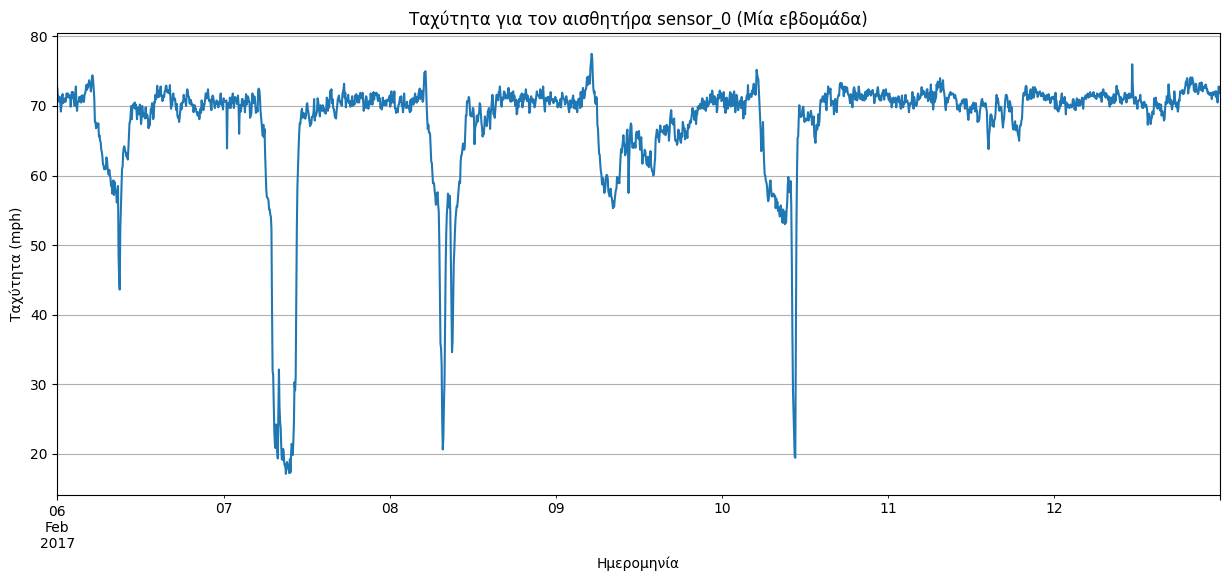

In [8]:
# Επιλογή ενός αισθητήρα (π.χ. ο πρώτος)
sensor_id = train_df.columns[0]

# Οπτικοποίηση για μία εβδομάδα
plt.figure(figsize=(15, 6))
train_df[sensor_id].loc['2017-02-06':'2017-02-12'].plot()
plt.title(f'Ταχύτητα για τον αισθητήρα {sensor_id} (Μία εβδομάδα)')
plt.ylabel('Ταχύτητα (mph)')
plt.xlabel('Ημερομηνία')
plt.grid(True)
plt.show()

In [ ]:
# 2. Διάγραμμα Αυτο-συσχέτισης (Autocorrelation Plot - ACF)

<Figure size 1500x600 with 0 Axes>

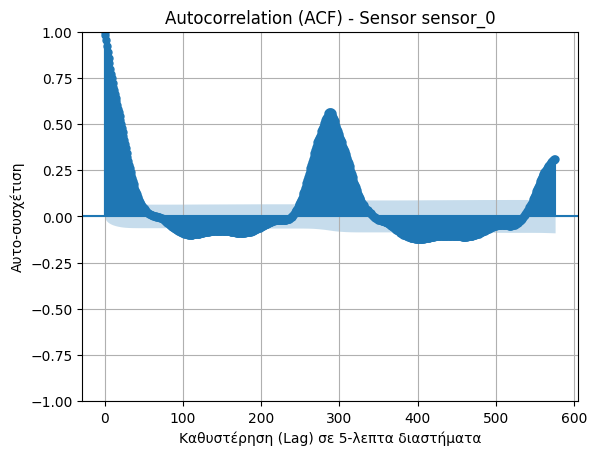

In [9]:
# Η ημέρα έχει 24 * 12 = 288 χρονικά βήματα (5-λεπτα)
lags = 288 * 2 # Δύο ημέρες

plt.figure(figsize=(15, 6))
plot_acf(train_df[sensor_id], lags=lags, title=f'Autocorrelation (ACF) - Sensor {sensor_id}')
plt.xlabel('Καθυστέρηση (Lag) σε 5-λεπτα διαστήματα')
plt.ylabel('Αυτο-συσχέτιση')
plt.grid(True)
plt.show()

In [ ]:
# 3. Ανάλυση σε Τάση, Εποχικότητα, Υπόλοιπα (Decomposition)

<Figure size 1500x1000 with 0 Axes>

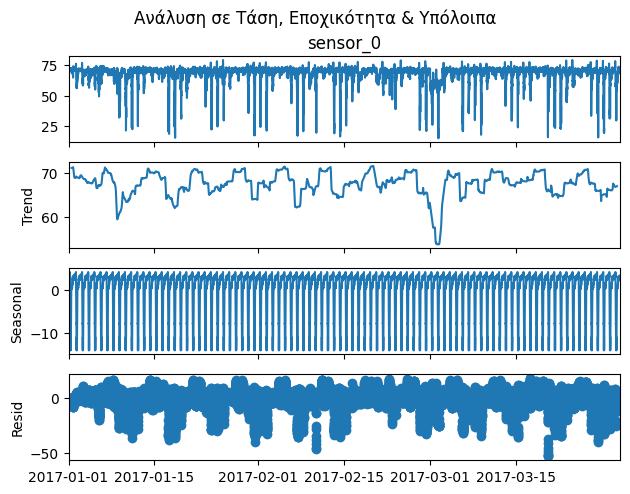

In [10]:
# Χρειαζόμαστε μια περίοδο. Για ημερήσια εποχικότητα, η περίοδος είναι 288.
result = seasonal_decompose(train_df[sensor_id], model='additive', period=288)

plt.figure(figsize=(15, 10))
result.plot()
plt.suptitle('Ανάλυση σε Τάση, Εποχικότητα & Υπόλοιπα', y=1.02)
plt.show()

In [12]:
# Βήμα III & IV: Κατασκευή Μοντέλου & Αξιολόγηση 

In [ ]:
# 1. Προετοιμασία Δεδομένων για το Μοντέλο (Supervised Learning Framing)

In [ ]:
# Πρέπει να μετατρέψουμε τη χρονοσειρά σε ζεύγη (input, output).

# Input (X): Μια ακολουθία από παρελθοντικές παρατηρήσεις (π.χ. οι τελευταίες 12 παρατηρήσεις, που αντιστοιχούν σε 1 ώρα).
# Output (Y): Η τιμή ή οι τιμές που θέλουμε να προβλέψουμε.
# Για την εργασία σας, έχετε δύο σενάρια πρόβλεψης:

# Σενάριο Α: Βραχυπρόθεσμη Πρόβλεψη

# Input Window: Π.χ., 12 βήματα (1 ώρα).
# Output Window: Τα επόμενα 12 βήματα (1 ώρα μπροστά, ανά 5 λεπτά).
# Σενάριο Β: Μεσοπρόθεσμη Πρόβλεψη

# Input Window: Π.χ., 24 βήματα (2 ώρες).
# Output Window: Τα επόμενα 12 βήματα, αλλά με ωριαίο βήμα (δηλ. πρόβλεψη για t+1h, t+2h, ..., t+12h).
# Ας υλοποιήσουμε μια συνάρτηση που δημιουργεί αυτά τα παράθυρα.

In [13]:
def create_sequences(input_data, target_data, history_size, target_size, step=1, target_step=1):
    X, y = [], []
    start_index = history_size
    end_index = len(input_data) - target_size * target_step
    
    for i in range(start_index, end_index):
        indices = range(i - history_size, i, step)
        X.append(input_data[indices])
        
        target_indices = range(i, i + target_size * target_step, target_step)
        y.append(target_data[target_indices])
        
    return np.array(X), np.array(y)

# --- Παράμετροι για Βραχυπρόθεσμη Πρόβλεψη ---
# Input: 12 βήματα (1 ώρα) | Output: 12 βήματα (επόμενη 1 ώρα ανά 5 λεπτά)
HISTORY_SIZE_SHORT = 12
TARGET_SIZE_SHORT = 12
TARGET_STEP_SHORT = 1 # Βήμα 1 (5 λεπτά)

# --- Παράμετροι για Μεσοπρόθεσμη Πρόβλεψη ---
# Input: 24 βήματα (2 ώρες) | Output: 12 βήματα (επόμενες 12 ώρες ανά 1 ώρα)
HISTORY_SIZE_MID = 24
TARGET_SIZE_MID = 12
HOURLY_STEP = 12 # 1 ώρα = 12 * 5 λεπτά
TARGET_STEP_MID = HOURLY_STEP

# Δημιουργία ακολουθιών για όλα τα δεδομένα (θα τα χωρίσουμε μετά)
# Σημείωση: Στην πράξη, αυτό γίνεται ξεχωριστά για train/val/test για να μην ανακατευτούν.
# Ο κώδικας εδώ είναι ενδεικτικός. Πρέπει να εφαρμοστεί στα train_scaled, val_scaled, test_scaled.

# Παράδειγμα για το test set (βραχυπρόθεσμο):
X_test_short, y_test_short = create_sequences(test_scaled.values, test_scaled.values,
                                              HISTORY_SIZE_SHORT, TARGET_SIZE_SHORT,
                                              target_step=TARGET_STEP_SHORT)

In [ ]:
# 2. Επιλογή και Εκπαίδευση Μοντέλου

Δημιουργία ακολουθιών για τα σύνολα train, val, test...

Ολοκληρώθηκε η δημιουργία ακολουθιών.
Σχήμα του X_train: (25884, 12, 325)
Σχήμα του y_train: (25884, 12, 325)
Σχήμα του X_val: (8616, 12, 325)
Σχήμα του y_val: (8616, 12, 325)
Σχήμα του X_test: (17544, 12, 325)
Σχήμα του y_test: (17544, 12, 325)

Κατασκευή του μοντέλου LSTM...


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_4 (LSTM)                   │ (None, 12, 64)         │        99,840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3900)           │       128,700 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 12, 325)        │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 240,956 (941.23 KB)

 Trainable params: 240,956 (941.23 KB)

 Non-trainable params: 0 (0.00 B)


Έναρξη εκπαίδευσης του μοντέλου...
Epoch 1/50
405/405 ━━━━━━━━━━━━━━━━━━━━ 8s 17ms/step - loss: 0.1978 - val_loss: 0.0606
Epoch 2/50
405/405 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - loss: 0.0584 - val_loss: 0.0544
Epoch 3/50
405/405 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - loss: 0.0498 - val_loss: 0.0505
Epoch 4/50
405/405 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - loss: 0.0462 - val_loss: 0.0477
Epoch 5/50
405/405 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - loss: 0.0446 - val_loss: 0.0468
Epoch 6/50
405/405 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - loss: 0.0435 - val_loss: 0.0460
Epoch 7/50
405/405 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - loss: 0.0425 - val_loss: 0.0468
Epoch 8/50
405/405 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - loss: 0.0417 - val_loss: 0.0464
Epoch 9/50
405/405 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - loss: 0.0408 - val_loss: 0.0443
Epoch 10/50
405/405 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - loss: 0.0398 - val_loss: 0.0446
Epoch 11/50
405/405 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - loss: 0.0398 - val_loss: 0.0440
Epoch

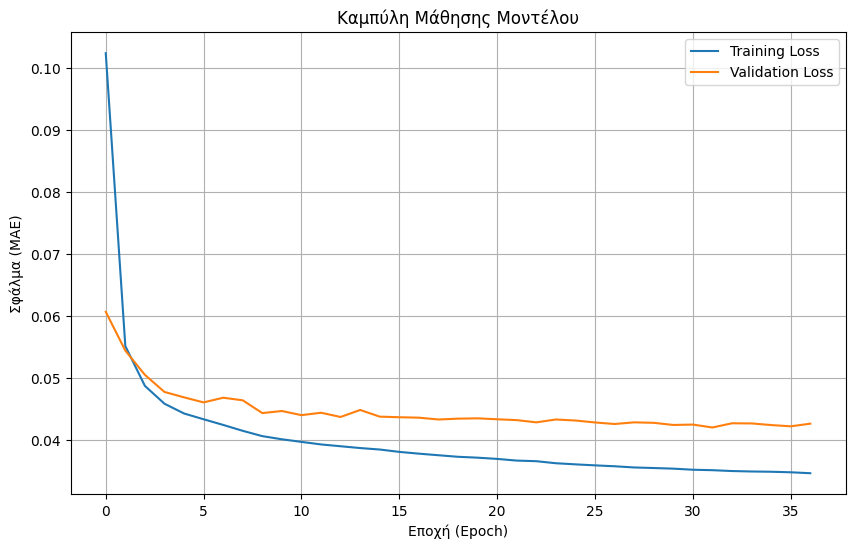


Πραγματοποίηση προβλέψεων στο test set...
549/549 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step
Σχήμα των προβλέψεων: (17544, 12, 325)
Σχήμα των πραγματικών τιμών: (17544, 12, 325)


In [16]:
# ==============================================================================
# 1. ΟΡΙΣΜΟΣ ΠΑΡΑΜΕΤΡΩΝ ΓΙΑ ΤΗ ΒΡΑΧΥΠΡΟΘΕΣΜΗ ΠΡΟΒΛΕΨΗ
# ==============================================================================

# Πόσα προηγούμενα χρονικά βήματα θα χρησιμοποιήσουμε για να κάνουμε πρόβλεψη.
# 1 ώρα ιστορικού = 12 βήματα των 5 λεπτών.
HISTORY_SIZE = 12

# Πόσα μελλοντικά χρονικά βήματα θέλουμε να προβλέψουμε.
# Την επόμενη 1 ώρα = 12 βήματα των 5 λεπτών.
TARGET_SIZE = 12

# Αριθμός αισθητήρων (χαρακτηριστικών)
# Υποθέτουμε ότι το train_scaled έχει στήλες μόνο για τους αισθητήρες.
NUM_SENSORS = train_scaled.shape[1]


# ==============================================================================
# 2. ΒΟΗΘΗΤΙΚΗ ΣΥΝΑΡΤΗΣΗ ΓΙΑ ΔΗΜΙΟΥΡΓΙΑ ΑΚΟΛΟΥΘΙΩΝ
# ==============================================================================

def create_sequences(data, history_size, target_size):
    """
    Μετατρέπει ένα DataFrame χρονοσειράς σε δείγματα κατάλληλα
    για supervised learning (X, y).
    """
    X, y = [], []
    # Ξεκινάμε από το σημείο όπου έχουμε αρκετό ιστορικό
    # και σταματάμε πριν το τέλος για να έχουμε αρκετό μέλλον για πρόβλεψη.
    start_index = history_size
    end_index = len(data) - target_size
    
    for i in range(start_index, end_index):
        # Το παράθυρο εισόδου (X): από (i - history_size) έως i
        indices_x = range(i - history_size, i)
        X.append(data[indices_x])
        
        # Το παράθυρο εξόδου (y): από i έως (i + target_size)
        indices_y = range(i, i + target_size)
        y.append(data[indices_y])
        
    return np.array(X), np.array(y)

# ==============================================================================
# 3. ΔΗΜΙΟΥΡΓΙΑ ΣΥΝΟΛΩΝ ΔΕΔΟΜΕΝΩΝ ΓΙΑ ΤΟ LSTM
# ==============================================================================

print("Δημιουργία ακολουθιών για τα σύνολα train, val, test...")

# Μετατρέπουμε τα DataFrames σε NumPy arrays για ταχύτητα
train_data = train_scaled.values
val_data = val_scaled.values
test_data = test_scaled.values

# Δημιουργία των ακολουθιών
X_train, y_train = create_sequences(train_data, HISTORY_SIZE, TARGET_SIZE)
X_val, y_val = create_sequences(val_data, HISTORY_SIZE, TARGET_SIZE)
X_test, y_test = create_sequences(test_data, HISTORY_SIZE, TARGET_SIZE)

print("\nΟλοκληρώθηκε η δημιουργία ακολουθιών.")
print("Σχήμα του X_train:", X_train.shape)
print("Σχήμα του y_train:", y_train.shape)
print("Σχήμα του X_val:", X_val.shape)
print("Σχήμα του y_val:", y_val.shape)
print("Σχήμα του X_test:", X_test.shape)
print("Σχήμα του y_test:", y_test.shape)
# Αναμενόμενα σχήματα:
# X: (πλήθος_δειγμάτων, HISTORY_SIZE, NUM_SENSORS) -> (π.χ. 25896, 12, 325)
# y: (πλήθος_δειγμάτων, TARGET_SIZE, NUM_SENSORS) -> (π.χ. 25896, 12, 325)


# ==============================================================================
# 4. ΚΑΤΑΣΚΕΥΗ ΤΟΥ ΜΟΝΤΕΛΟΥ LSTM
# ==============================================================================

print("\nΚατασκευή του μοντέλου LSTM...")

model = Sequential()

# Στρώμα εισόδου: καθορίζει το σχήμα της εισόδου μας
# (12 χρονικά βήματα, 325 αισθητήρες ανά βήμα)
model.add(Input(shape=(HISTORY_SIZE, NUM_SENSORS)))

# Πρώτο στρώμα LSTM. `return_sequences=True` είναι απαραίτητο για να
# τροφοδοτήσουμε την έξοδο αυτού του στρώματος στο επόμενο LSTM στρώμα.
model.add(LSTM(units=64, return_sequences=True))

# Δεύτερο στρώμα LSTM. `return_sequences=False` (η προεπιλογή) γιατί
# θέλουμε να συνοψίσει την ακολουθία σε ένα μόνο διάνυσμα εξόδου.
model.add(LSTM(units=32))

# Πλήρως συνδεδεμένο (Dense) στρώμα εξόδου.
# Ο αριθμός των νευρώνων πρέπει να είναι ίσος με τον αριθμό των τιμών που
# θέλουμε να προβλέψουμε: 12 βήματα * 325 αισθητήρες.
model.add(Dense(units=TARGET_SIZE * NUM_SENSORS))

# (Προαιρετικό αλλά χρήσιμο) Αλλάζουμε το σχήμα της επίπεδης εξόδου
# πίσω σε (12, 325) για ευκολότερη αξιολόγηση.
model.add(Reshape((TARGET_SIZE, NUM_SENSORS)))


# ==============================================================================
# 5. ΜΕΤΑΓΛΩΤΤΙΣΗ ΚΑΙ ΕΚΠΑΙΔΕΥΣΗ ΤΟΥ ΜΟΝΤΕΛΟΥ
# ==============================================================================

# Ορίζουμε το EarlyStopping callback για να σταματήσει η εκπαίδευση όταν
# η απόδοση στο validation set δεν βελτιώνεται, αποφεύγοντας το overfitting.
early_stopping = EarlyStopping(
    monitor='val_loss',  # Παρακολούθηση της απώλειας στο σύνολο επικύρωσης
    patience=5,          # Αριθμός εποχών χωρίς βελτίωση πριν σταματήσει
    restore_best_weights=True # Επαναφορά των βαρών του μοντέλου από την καλύτερη εποχή
)

# Μεταγλώττιση (compilation) του μοντέλου.
# optimizer='adam' είναι μια στιβαρή επιλογή για τα περισσότερα προβλήματα.
# loss='mae' (Mean Absolute Error) είναι καλή επιλογή για πρόβλεψη χρονοσειρών.
model.compile(optimizer='adam', loss='mae')

# Εκτύπωση της σύνοψης της αρχιτεκτονικής του μοντέλου
model.summary()

print("\nΈναρξη εκπαίδευσης του μοντέλου...")

# Εκπαίδευση του μοντέλου
history = model.fit(
    X_train, y_train,
    epochs=50,  # Μέγιστος αριθμός εποχών (το EarlyStopping πιθανότατα θα σταματήσει νωρίτερα)
    batch_size=64,
    validation_data=(X_val, y_val),
    callbacks=[early_stopping],
    verbose=1 # Δείχνει μια μπάρα προόδου
)

print("\nΗ εκπαίδευση ολοκληρώθηκε.")

# ==============================================================================
# 6. ΟΠΤΙΚΟΠΟΙΗΣΗ ΑΠΩΛΕΙΑΣ ΚΑΙ ΠΡΟΒΛΕΨΗ (ΠΑΡΑΔΕΙΓΜΑ)
# ==============================================================================

# Οπτικοποίηση της καμπύλης μάθησης
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Καμπύλη Μάθησης Μοντέλου')
plt.xlabel('Εποχή (Epoch)')
plt.ylabel('Σφάλμα (MAE)')
plt.legend()
plt.grid(True)
plt.show()

# Τώρα το μοντέλο είναι εκπαιδευμένο. Το επόμενο βήμα είναι η αξιολόγηση
# στο test set

print("\nΠραγματοποίηση προβλέψεων στο test set...")
# Η `predict` επιστρέφει τις προβλέψεις σε κανονικοποιημένη κλίμακα [0,1]
predictions_scaled = model.predict(X_test)

print("Σχήμα των προβλέψεων:", predictions_scaled.shape)
print("Σχήμα των πραγματικών τιμών:", y_test.shape)

In [20]:
# ==============================================================================
# 1. ΑΝΤΙΣΤΡΟΦΗ ΚΑΝΟΝΙΚΟΠΟΙΗΣΗΣ (INVERSE SCALING)
# ==============================================================================

print("Αντιστροφή της κανονικοποίησης για προβλέψεις και πραγματικές τιμές...")

# Ο scaler περιμένει δεδομένα 2D (samples, features).
# Τα δεδομένα μας είναι 3D (samples, timesteps, features).
# Πρέπει να τα "ισιώσουμε" (reshape) πριν τα δώσουμε στον scaler.

# Σχήμα πριν: (num_samples, TARGET_SIZE, NUM_SENSORS)
# π.χ., (8593, 12, 325)

# Αλλάζουμε το σχήμα σε 2D: (num_samples * TARGET_SIZE, NUM_SENSORS)
pred_reshaped = predictions_scaled.reshape(-1, NUM_SENSORS)
y_test_reshaped = y_test.reshape(-1, NUM_SENSORS)

# Εφαρμόζουμε το inverse_transform
predictions_real = scaler.inverse_transform(pred_reshaped)
y_test_real = scaler.inverse_transform(y_test_reshaped)

# Επαναφέρουμε τα δεδομένα στο αρχικό τους 3D σχήμα για ευκολότερη ανάλυση
# Σχήμα μετά: (num_samples, TARGET_SIZE, NUM_SENSORS)
predictions_real = predictions_real.reshape(predictions_scaled.shape)
y_test_real = y_test_real.reshape(y_test.shape)

print("Ολοκληρώθηκε η αντιστροφή.")
print("Σχήμα πραγματικών τιμών (y_test_real):", y_test_real.shape)
print("Σχήμα προβλέψεων (predictions_real):", predictions_real.shape)


# ==============================================================================
# 2. ΥΠΟΛΟΓΙΣΜΟΣ ΜΕΤΡΙΚΩΝ ΑΝΑ ΧΡΟΝΙΚΟ ΟΡΙΖΟΝΤΑ
# ==============================================================================

print("\nΥπολογισμός μετρικών αξιολόγησης ανά χρονικό ορίζοντα...")

# Δημιουργούμε ένα λεξικό για να αποθηκεύσουμε τα αποτελέσματα
results = {}

# Το y_test_real και predictions_real έχουν σχήμα (num_samples, target_size, num_sensors)
# target_size είναι 12 (για τα 12 βήματα των 5 λεπτών)
# num_sensors είναι 325

# Επανάληψη για κάθε ένα από τα 12 βήματα πρόβλεψης (horizons)
for horizon_step in range(y_test_real.shape[1]): # y_test_real.shape[1] είναι το TARGET_SIZE (12)
    
    # Παίρνουμε τις τιμές για όλους τους αισθητήρες και όλα τα δείγματα
    # για τον συγκεκριμένο χρονικό ορίζοντα.
    true_values_hr = y_test_real[:, horizon_step, :]
    pred_values_hr = predictions_real[:, horizon_step, :]
    
    # Λίστες για να αποθηκεύσουμε το σφάλμα για κάθε αισθητήρα ξεχωριστά
    mae_per_sensor = []
    mape_per_sensor = []
    rmse_per_sensor = []
    r2_per_sensor = []
    
    # Επανάληψη για κάθε αισθητήρα
    for sensor_idx in range(NUM_SENSORS):
        true_sensor = true_values_hr[:, sensor_idx]
        pred_sensor = pred_values_hr[:, sensor_idx]

        # Υπολογισμός MAE
        mae_per_sensor.append(mean_absolute_error(true_sensor, pred_sensor))
        
        # Υπολογισμός RMSE
        rmse_per_sensor.append(np.sqrt(mean_squared_error(true_sensor, pred_sensor)))
        
        # Υπολογισμός R2
        r2_per_sensor.append(r2_score(true_sensor, pred_sensor))
        
        # Υπολογισμός MAPE. ΠΡΟΣΟΧΗ: Αποφεύγουμε τη διαίρεση με το μηδέν.
        # Δημιουργούμε μια μάσκα για να επιλέξουμε μόνο τις μη μηδενικές πραγματικές τιμές.
        mask = true_sensor != 0
        if np.any(mask): # Αν υπάρχει τουλάχιστον μία μη μηδενική τιμή
            mape = np.mean(np.abs((true_sensor[mask] - pred_sensor[mask]) / true_sensor[mask])) * 100
            mape_per_sensor.append(mape)
        else: # Αν όλες οι τιμές είναι μηδέν, το MAPE είναι 0
            mape_per_sensor.append(0)

    # Αφού έχουμε υπολογίσει τις μετρικές για όλους τους 325 αισθητήρες,
    # υπολογίζουμε τη μέση τιμή και την τυπική απόκλιση τους.
    horizon_label = f't+{5 * (horizon_step + 1)} min' # Δημιουργία ετικέτας, π.χ., t+5 min, t+10 min ... t+60 min

    results[horizon_label] = {
        'MAE': (np.mean(mae_per_sensor), np.std(mae_per_sensor)),
        'MAPE (%)': (np.mean(mape_per_sensor), np.std(mape_per_sensor)),
        'RMSE': (np.mean(rmse_per_sensor), np.std(rmse_per_sensor)),
        'R2': (np.mean(r2_per_sensor), np.std(r2_per_sensor))
    }

print("Ολοκληρώθηκε ο υπολογισμός των μετρικών.")

# ==============================================================================
# 3. ΔΗΜΙΟΥΡΓΙΑ ΚΑΙ ΕΚΤΥΠΩΣΗ ΤΟΥ ΤΕΛΙΚΟΥ ΠΙΝΑΚΑ
# ==============================================================================

# Μετατροπή του λεξικού σε DataFrame για ωραία εμφάνιση
results_df = pd.DataFrame.from_dict(results, orient='index')

# Μορφοποίηση των κελιών για να δείχνουν "μέση τιμή ± τυπική απόκλιση"
# με 3 δεκαδικά ψηφία.
formatted_df = pd.DataFrame(index=results_df.index)
for col in results_df.columns:
    formatted_df[col] = results_df[col].apply(lambda x: f"{x[0]:.3f} ± {x[1]:.3f}")

# Ορισμός της εμφάνισης του pandas για να φαίνονται όλες οι στήλες
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 120)

print("\n" + "="*80)
print(" ΑΠΟΤΕΛΕΣΜΑΤΑ ΑΞΙΟΛΟΓΗΣΗΣ - ΒΡΑΧΥΠΡΟΘΕΣΜΗ ΠΡΟΒΛΕΨΗ (1 ΩΡΑ) ".center(80, "="))
print("="*80)
print("Οι τιμές αναγράφονται στη μορφή: Μέση Τιμή ± Τυπική Απόκλιση (για όλους τους αισθητήρες)")
print(formatted_df)
print("="*80)

Αντιστροφή της κανονικοποίησης για προβλέψεις και πραγματικές τιμές...
Ολοκληρώθηκε η αντιστροφή.
Σχήμα πραγματικών τιμών (y_test_real): (17544, 12, 325)
Σχήμα προβλέψεων (predictions_real): (17544, 12, 325)

Υπολογισμός μετρικών αξιολόγησης ανά χρονικό ορίζοντα...
Ολοκληρώθηκε ο υπολογισμός των μετρικών.

========== ΑΠΟΤΕΛΕΣΜΑΤΑ ΑΞΙΟΛΟΓΗΣΗΣ - ΒΡΑΧΥΠΡΟΘΕΣΜΗ ΠΡΟΒΛΕΨΗ (1 ΩΡΑ) ===========
Οι τιμές αναγράφονται στη μορφή: Μέση Τιμή ± Τυπική Απόκλιση (για όλους τους αισθητήρες)
                    MAE       MAPE (%)           RMSE             R2
t+5 min   2.818 ± 1.173  7.082 ± 4.431  5.297 ± 2.011  0.545 ± 0.288
t+10 min  2.822 ± 1.178  7.062 ± 4.409  5.302 ± 2.006  0.544 ± 0.289
t+15 min  2.822 ± 1.183  7.041 ± 4.395  5.306 ± 2.003  0.545 ± 0.286
t+20 min  2.824 ± 1.182  7.020 ± 4.348  5.312 ± 1.994  0.546 ± 0.283
t+25 min  2.834 ± 1.186  7.023 ± 4.334  5.333 ± 1.997  0.545 ± 0.280
t+30 min  2.856 ± 1.190  7.050 ± 4.335  5.361 ± 2.006  0.543 ± 0.280
t+35 min  2.875 ± 1.194  7.070 ± 4.321 

In [19]:
# ==============================================================================
#            ΜΕΣΟΠΡΟΘΕΣΜΗ ΠΡΟΒΛΕΨΗ (12 ΩΡΕΣ) 
# ==============================================================================

# 1. ΟΡΙΣΜΟΣ ΠΑΡΑΜΕΤΡΩΝ
HISTORY_SIZE_MID = 24
TARGET_SIZE_MID = 12
TARGET_STEP_MID = 12 # 1 ώρα = 12 * 5 λεπτά

# 2. ΠΡΟΣΑΡΜΟΣΜΕΝΗ ΒΟΗΘΗΤΙΚΗ ΣΥΝΑΡΤΗΣΗ
def create_sequences_with_step(data, history_size, target_size, target_step):
    X, y = [], []
    max_future_offset = target_size * target_step - 1
    stop_index = len(data) - max_future_offset
    
    for i in range(history_size, stop_index):
        indices_x = range(i - history_size, i)
        X.append(data[indices_x])
        indices_y = [i + j * target_step - 1 for j in range(1, target_size + 1)]
        y.append(data[indices_y])
        
    return np.array(X), np.array(y)

# 3. ΔΗΜΙΟΥΡΓΙΑ ΣΥΝΟΛΩΝ ΔΕΔΟΜΕΝΩΝ
print("Δημιουργία ακολουθιών για μεσοπρόθεσμη πρόβλεψη...")
train_data = train_scaled.values
val_data = val_scaled.values
test_data = test_scaled.values

X_train_mid, y_train_mid = create_sequences_with_step(train_data, HISTORY_SIZE_MID, TARGET_SIZE_MID, TARGET_STEP_MID)
X_val_mid, y_val_mid = create_sequences_with_step(val_data, HISTORY_SIZE_MID, TARGET_SIZE_MID, TARGET_STEP_MID)
X_test_mid, y_test_mid = create_sequences_with_step(test_data, HISTORY_SIZE_MID, TARGET_SIZE_MID, TARGET_STEP_MID)

print("\nΟλοκληρώθηκε η δημιουργία ακολουθιών.")
print("Σχήμα του X_train_mid:", X_train_mid.shape)
print("Σχήμα του y_train_mid:", y_train_mid.shape)
print("Σχήμα του X_test_mid:", X_test_mid.shape)
print("Σχήμα του y_test_mid:", y_test_mid.shape)

# 4. ΚΑΤΑΣΚΕΥΗ, ΕΚΠΑΙΔΕΥΣΗ ΚΑΙ ΑΞΙΟΛΟΓΗΣΗ
model_mid = Sequential([
    Input(shape=(HISTORY_SIZE_MID, NUM_SENSORS)),
    LSTM(64, return_sequences=True),
    LSTM(32),
    Dense(TARGET_SIZE_MID * NUM_SENSORS),
    Reshape((TARGET_SIZE_MID, NUM_SENSORS))
])
model_mid.compile(optimizer='adam', loss='mae')
model_mid.summary()

print("\nΈναρξη εκπαίδευσης του μεσοπρόθεσμου μοντέλου...")
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
history_mid = model_mid.fit(
    X_train_mid, y_train_mid,
    epochs=50, batch_size=64,
    validation_data=(X_val_mid, y_val_mid),
    callbacks=[early_stopping], verbose=1
)
print("\nΗ εκπαίδευση ολοκληρώθηκε.")

# 5. ΑΞΙΟΛΟΓΗΣΗ
print("\nΠραγματοποίηση προβλέψεων στο test set...")
predictions_scaled_mid = model_mid.predict(X_test_mid)

print("Αντιστροφή της κανονικοποίησης...")
pred_reshaped_mid = predictions_scaled_mid.reshape(-1, NUM_SENSORS)
y_test_reshaped_mid = y_test_mid.reshape(-1, NUM_SENSORS)
predictions_real_mid = scaler.inverse_transform(pred_reshaped_mid)
y_test_real_mid = scaler.inverse_transform(y_test_reshaped_mid)
predictions_real_mid = predictions_real_mid.reshape(predictions_scaled_mid.shape)
y_test_real_mid = y_test_real_mid.reshape(y_test_mid.shape)

print("Υπολογισμός μετρικών αξιολόγησης...")
results_mid = {}
for horizon_step in range(y_test_real_mid.shape[1]):
    true_values_hr = y_test_real_mid[:, horizon_step, :]
    pred_values_hr = predictions_real_mid[:, horizon_step, :]
    mae_per_sensor, mape_per_sensor, rmse_per_sensor, r2_per_sensor = [], [], [], []
    for sensor_idx in range(NUM_SENSORS):
        true_sensor = true_values_hr[:, sensor_idx]
        pred_sensor = pred_values_hr[:, sensor_idx]
        mae_per_sensor.append(mean_absolute_error(true_sensor, pred_sensor))
        rmse_per_sensor.append(np.sqrt(mean_squared_error(true_sensor, pred_sensor)))
        r2_per_sensor.append(r2_score(true_sensor, pred_sensor))
        mask = true_sensor != 0
        if np.any(mask):
            mape_per_sensor.append(np.mean(np.abs((true_sensor[mask] - pred_sensor[mask]) / true_sensor[mask])) * 100)
        else:
            mape_per_sensor.append(0)
    horizon_label = f't+{(horizon_step + 1)} h' 
    results_mid[horizon_label] = {
        'MAE': (np.mean(mae_per_sensor), np.std(mae_per_sensor)),
        'MAPE (%)': (np.mean(mape_per_sensor), np.std(mape_per_sensor)),
        'RMSE': (np.mean(rmse_per_sensor), np.std(rmse_per_sensor)),
        'R2': (np.mean(r2_per_sensor), np.std(r2_per_sensor))
    }

# 6. ΠΑΡΟΥΣΙΑΣΗ ΑΠΟΤΕΛΕΣΜΑΤΩΝ
results_df_mid = pd.DataFrame.from_dict(results_mid, orient='index')
formatted_df_mid = pd.DataFrame(index=results_df_mid.index)
for col in results_df_mid.columns:
    formatted_df_mid[col] = results_df_mid[col].apply(lambda x: f"{x[0]:.3f} ± {x[1]:.3f}")

print("\n" + "="*80)
print(" ΑΠΟΤΕΛΕΣΜΑΤΑ ΑΞΙΟΛΟΓΗΣΗΣ - ΜΕΣΟΠΡΟΘΕΣΜΗ ΠΡΟΒΛΕΨΗ (12 ΩΡΕΣ) ".center(80, "="))
print("="*80)
print(formatted_df_mid)
print("="*80)

Δημιουργία ακολουθιών για μεσοπρόθεσμη πρόβλεψη (Διορθωμένη έκδοση)...

Ολοκληρώθηκε η δημιουργία ακολουθιών.
Σχήμα του X_train_mid: (25741, 24, 325)
Σχήμα του y_train_mid: (25741, 12, 325)
Σχήμα του X_test_mid: (17401, 24, 325)
Σχήμα του y_test_mid: (17401, 12, 325)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_6 (LSTM)                   │ (None, 24, 64)         │        99,840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_7 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3900)           │       128,700 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_1 (Reshape)             │ (None, 12, 325)        │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 240,956 (941.23 KB)

 Trainable params: 240,956 (941.23 KB)

 Non-trainable params: 0 (0.00 B)


Έναρξη εκπαίδευσης του μεσοπρόθεσμου μοντέλου...
Epoch 1/50
403/403 ━━━━━━━━━━━━━━━━━━━━ 13s 29ms/step - loss: 0.1975 - val_loss: 0.0710
Epoch 2/50
403/403 ━━━━━━━━━━━━━━━━━━━━ 8s 19ms/step - loss: 0.0743 - val_loss: 0.0680
Epoch 3/50
403/403 ━━━━━━━━━━━━━━━━━━━━ 8s 19ms/step - loss: 0.0710 - val_loss: 0.0648
Epoch 4/50
403/403 ━━━━━━━━━━━━━━━━━━━━ 8s 19ms/step - loss: 0.0676 - val_loss: 0.0643
Epoch 5/50
403/403 ━━━━━━━━━━━━━━━━━━━━ 8s 20ms/step - loss: 0.0658 - val_loss: 0.0628
Epoch 6/50
403/403 ━━━━━━━━━━━━━━━━━━━━ 8s 20ms/step - loss: 0.0625 - val_loss: 0.0610
Epoch 7/50
403/403 ━━━━━━━━━━━━━━━━━━━━ 8s 19ms/step - loss: 0.0601 - val_loss: 0.0617
Epoch 8/50
403/403 ━━━━━━━━━━━━━━━━━━━━ 8s 20ms/step - loss: 0.0582 - val_loss: 0.0586
Epoch 9/50
403/403 ━━━━━━━━━━━━━━━━━━━━ 9s 22ms/step - loss: 0.0562 - val_loss: 0.0593
Epoch 10/50
403/403 ━━━━━━━━━━━━━━━━━━━━ 9s 21ms/step - loss: 0.0555 - val_loss: 0.0601
Epoch 11/50
403/403 ━━━━━━━━━━━━━━━━━━━━ 8s 20ms/step - loss: 0.0552 - val_los